In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/DSPL_Individual/Datasets/Original/insurance.data.aggregated.csv')

In [39]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Marketing Channel,Device Category,Users,Pages / Session,Avg. Session Duration,TotalNumberOfInsurancePoliciesPurchaed,Revenue,TotalNumberOfInsuranceQuotes
0,(Other),desktop,1,1.00,0.00,0,0.00,0
1,Affiliates,desktop,11,3.36,266.00,0,0.00,3
2,Affiliates,mobile,4,4.83,138.50,0,0.00,4
3,Aggregators,desktop,15,1.94,125.79,9,114.89,4
4,Aggregators,mobile,20,1.85,126.24,12,278.00,10


In [40]:
# Get the number of rows and columns
num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 1933
Number of columns: 8


In [41]:
# Display column names
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- Marketing Channel
- Device Category
- Users
- Pages / Session
- Avg. Session Duration
- TotalNumberOfInsurancePoliciesPurchaed
- Revenue
- TotalNumberOfInsuranceQuotes


In [42]:
# Display concise summary of the DataFrame, including data types
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1933 entries, 0 to 1932
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Marketing Channel                       1933 non-null   object 
 1   Device Category                         1933 non-null   object 
 2   Users                                   1933 non-null   int64  
 3   Pages / Session                         1933 non-null   float64
 4   Avg. Session Duration                   1933 non-null   float64
 5   TotalNumberOfInsurancePoliciesPurchaed  1933 non-null   int64  
 6   Revenue                                 1933 non-null   float64
 7   TotalNumberOfInsuranceQuotes            1933 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 120.9+ KB


In [43]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Users,Pages / Session,Avg. Session Duration,TotalNumberOfInsurancePoliciesPurchaed,Revenue,TotalNumberOfInsuranceQuotes
count,1933.000000,1933.000000,1933.000000,1933.000000,1933.00000,1933.000000
mean,37.710295,2.932556,144.079146,2.456803,65.62522,8.994827
std,64.933816,1.986642,170.966991,4.860350,151.76103,22.564033
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,1.640000,49.580000,0.000000,0.00000,1.000000
50%,10.000000,2.450000,111.330000,0.000000,0.00000,3.000000
75%,39.000000,3.500000,178.280000,2.000000,44.80000,7.000000
max,370.000000,26.000000,2984.000000,34.000000,1395.62000,201.000000


In [44]:
# Display descriptive statistics for all columns, including categorical
print("\nDescriptive Statistics (including categorical data):")
display(df.describe(include='all'))


Descriptive Statistics (including categorical data):


,Marketing Channel,Device Category,Users,Pages / Session,Avg. Session Duration,TotalNumberOfInsurancePoliciesPurchaed,Revenue,TotalNumberOfInsuranceQuotes
count,1933,1933,1933.000000,1933.000000,1933.000000,1933.000000,1933.00000,1933.000000
unique,11,3,NaN,NaN,NaN,NaN,NaN,NaN
top,Paid Search,mobile,NaN,NaN,NaN,NaN,NaN,NaN
freq,271,862,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,37.710295,2.932556,144.079146,2.456803,65.62522,8.994827
std,NaN,NaN,64.933816,1.986642,170.966991,4.860350,151.76103,22.564033
min,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,NaN,NaN,3.000000,1.640000,49.580000,0.000000,0.00000,1.000000
50%,NaN,NaN,10.000000,2.450000,111.330000,0.000000,0.00000,3.000000
75%,NaN,NaN,39.000000,3.500000,178.280000,2.000000,44.80000,7.000000


In [45]:
print('--- Checking for Missing Values ---\n')
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if (missing_values == 0).all():
    print('No missing values found.\n')

print('--- Checking for Duplicate Rows ---\n')
duplicate_rows = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_rows}\n')
if duplicate_rows == 0:
    print('No duplicate rows found.\n')

print('--- Checking for Incorrect Data Types (from df.info() previously) ---\n')
print('As per `df.info()` output, data types appear appropriate for each column.\n')

print('--- Checking for Strange Values (e.g., negative numbers in positive-only metrics) ---\n')
positive_only_cols = ['Users', 'Pages / Session', 'Avg. Session Duration', 'TotalNumberOfInsurancePoliciesPurchaed', 'Revenue', 'TotalNumberOfInsuranceQuotes']

issues_found = False
for col in positive_only_cols:
    if (df[col] < 0).any():
        print(f'Negative values found in column: {col}')
        print(df[df[col] < 0][col])
        issues_found = True

if not issues_found:
    print('No negative values found in Users, Pages / Session, Avg. Session Duration, TotalNumberOfInsurancePoliciesPurchaed, Revenue, and TotalNumberOfInsuranceQuotes.\n')
else:
    print('Further investigation might be needed for columns with negative values.\n')


--- Checking for Missing Values ---

Series([], dtype: int64)
No missing values found.

--- Checking for Duplicate Rows ---

Number of duplicate rows: 162

--- Checking for Incorrect Data Types (from df.info() previously) ---

As per `df.info()` output, data types appear appropriate for each column.

--- Checking for Strange Values (e.g., negative numbers in positive-only metrics) ---

No negative values found in Users, Pages / Session, Avg. Session Duration, TotalNumberOfInsurancePoliciesPurchaed, Revenue, and TotalNumberOfInsuranceQuotes.



In [46]:
print('--- First 20 Duplicate Rows ---\n')
display(df[df.duplicated()].head(20))

--- First 20 Duplicate Rows ---



,Marketing Channel,Device Category,Users,Pages / Session,Avg. Session Duration,TotalNumberOfInsurancePoliciesPurchaed,Revenue,TotalNumberOfInsuranceQuotes
30,Display,mobile,1,1.0,0.0,0,0.0,0
68,(Other),desktop,1,1.0,0.0,0,0.0,0
117,(Other),desktop,1,1.0,0.0,0,0.0,0
137,Social,mobile,1,1.0,0.0,0,0.0,0
170,Organic Search,tablet,1,1.0,0.0,0,0.0,0
194,Paid Social,tablet,1,1.0,0.0,0,0.0,0
302,Organic Search,tablet,2,1.0,0.0,0,0.0,0
305,Paid Search,tablet,1,1.0,0.0,0,0.0,0
316,Direct,tablet,1,1.0,0.0,0,0.0,0
336,Display,desktop,1,1.0,0.0,0,0.0,0


In [55]:
import os

# Define the path to save the cleaned dataset
gdrive_folder_path = '/content/drive/MyDrive/DSPL_Individual/Datasets/Cleaned'
output_file_name = 'insurance_cleaned.csv'
full_output_path = os.path.join(gdrive_folder_path, output_file_name)

# Create the directory if it doesn't exist
os.makedirs(gdrive_folder_path, exist_ok=True)

# Save the cleaned DataFrame to CSV
df.to_csv(full_output_path, index=False)

print(f"Cleaned dataset saved successfully to: {full_output_path}")

Cleaned dataset saved successfully to: /content/drive/MyDrive/DSPL_Individual/Datasets/Cleaned/insurance_cleaned.csv


## Step 4: Perform EDA

### EDA 1 – Marketing Channels

Let's analyze the marketing channels to answer the following questions:
- Which marketing channel brings the most users?
- Which generates the most revenue?
- Which produces the most quotes?
- Which sells the most policies?

We will visualize these using sorted bar charts.

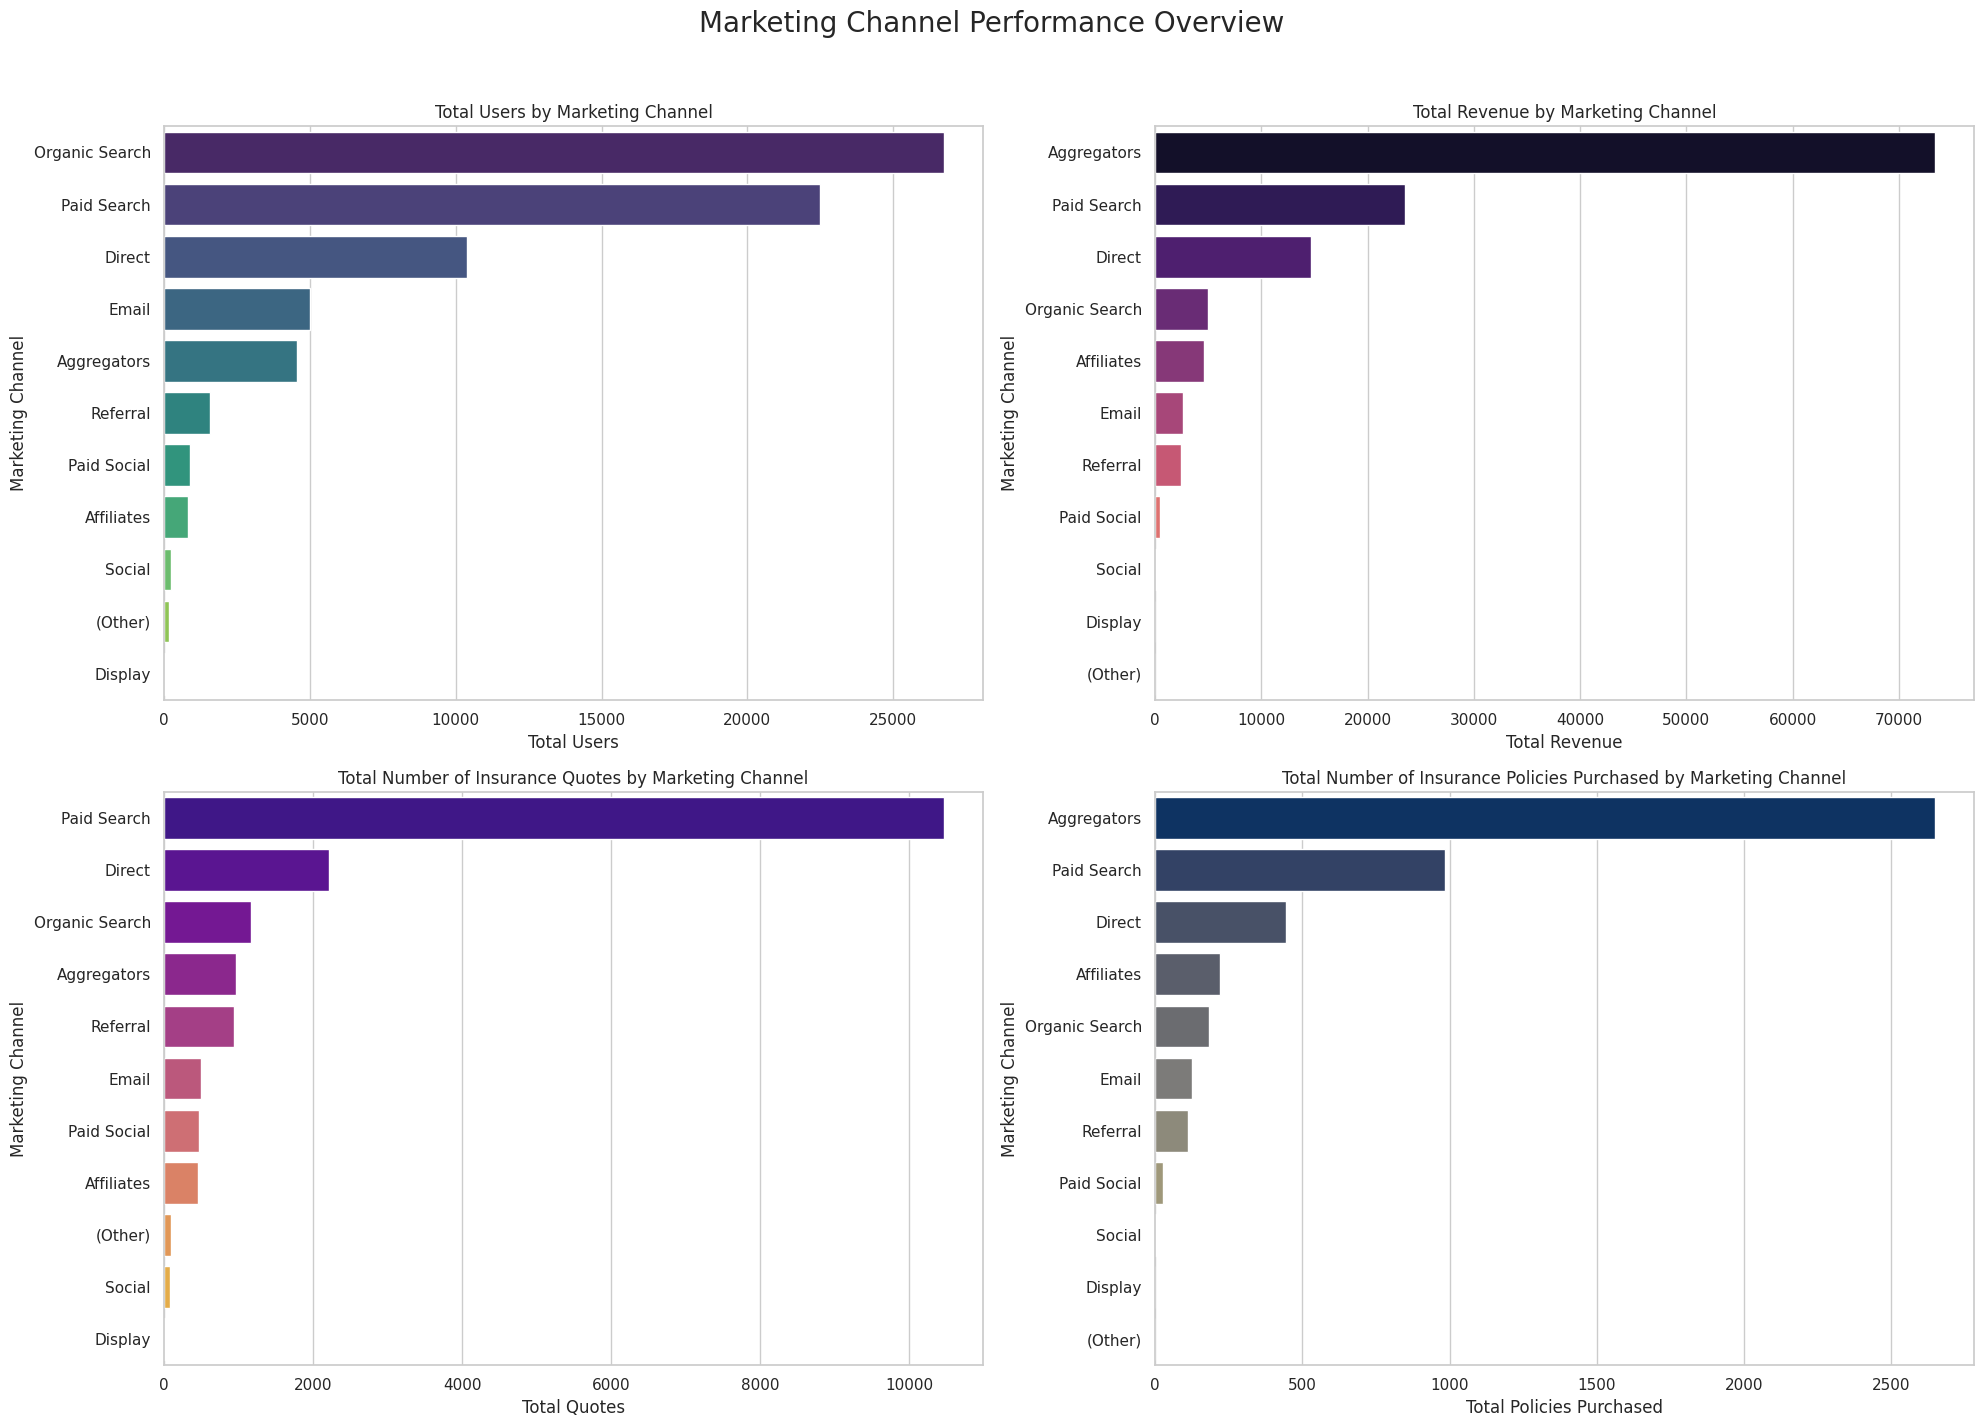

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data by 'Marketing Channel'
marketing_channel_df = df.groupby('Marketing Channel').agg(
    total_users=('Users', 'sum'),
    total_revenue=('Revenue', 'sum'),
    total_quotes=('TotalNumberOfInsuranceQuotes', 'sum'),
    total_policies=('TotalNumberOfInsurancePoliciesPurchaed', 'sum')
).reset_index()

# Set up the plotting style
sns.set_theme(style="whitegrid")

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Marketing Channel Performance Overview', fontsize=20)

# Plot 1: Total Users by Marketing Channel
sns.barplot(x='total_users', y='Marketing Channel', data=marketing_channel_df.sort_values(by='total_users', ascending=False), palette='viridis', ax=axes[0, 0], hue='Marketing Channel', legend=False)
axes[0, 0].set_title('Total Users by Marketing Channel')
axes[0, 0].set_xlabel('Total Users')
axes[0, 0].set_ylabel('Marketing Channel')

# Plot 2: Total Revenue by Marketing Channel
sns.barplot(x='total_revenue', y='Marketing Channel', data=marketing_channel_df.sort_values(by='total_revenue', ascending=False), palette='magma', ax=axes[0, 1], hue='Marketing Channel', legend=False)
axes[0, 1].set_title('Total Revenue by Marketing Channel')
axes[0, 1].set_xlabel('Total Revenue')
axes[0, 1].set_ylabel('Marketing Channel')

# Plot 3: Total Number of Insurance Quotes by Marketing Channel
sns.barplot(x='total_quotes', y='Marketing Channel', data=marketing_channel_df.sort_values(by='total_quotes', ascending=False), palette='plasma', ax=axes[1, 0], hue='Marketing Channel', legend=False)
axes[1, 0].set_title('Total Number of Insurance Quotes by Marketing Channel')
axes[1, 0].set_xlabel('Total Quotes')
axes[1, 0].set_ylabel('Marketing Channel')

# Plot 4: Total Number of Insurance Policies Purchased by Marketing Channel
sns.barplot(x='total_policies', y='Marketing Channel', data=marketing_channel_df.sort_values(by='total_policies', ascending=False), palette='cividis', ax=axes[1, 1], hue='Marketing Channel', legend=False)
axes[1, 1].set_title('Total Number of Insurance Policies Purchased by Marketing Channel')
axes[1, 1].set_xlabel('Total Policies Purchased')
axes[1, 1].set_ylabel('Marketing Channel')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

### EDA 2 – Device Category

Now, let's analyze the `Device Category` to understand its impact on key metrics:
- Which device category has the highest revenue?
- Which device category has the highest users?
- Which device category converts better (e.g., in terms of policies purchased per user)?

We will use bar charts and potentially a pie chart for visualization.

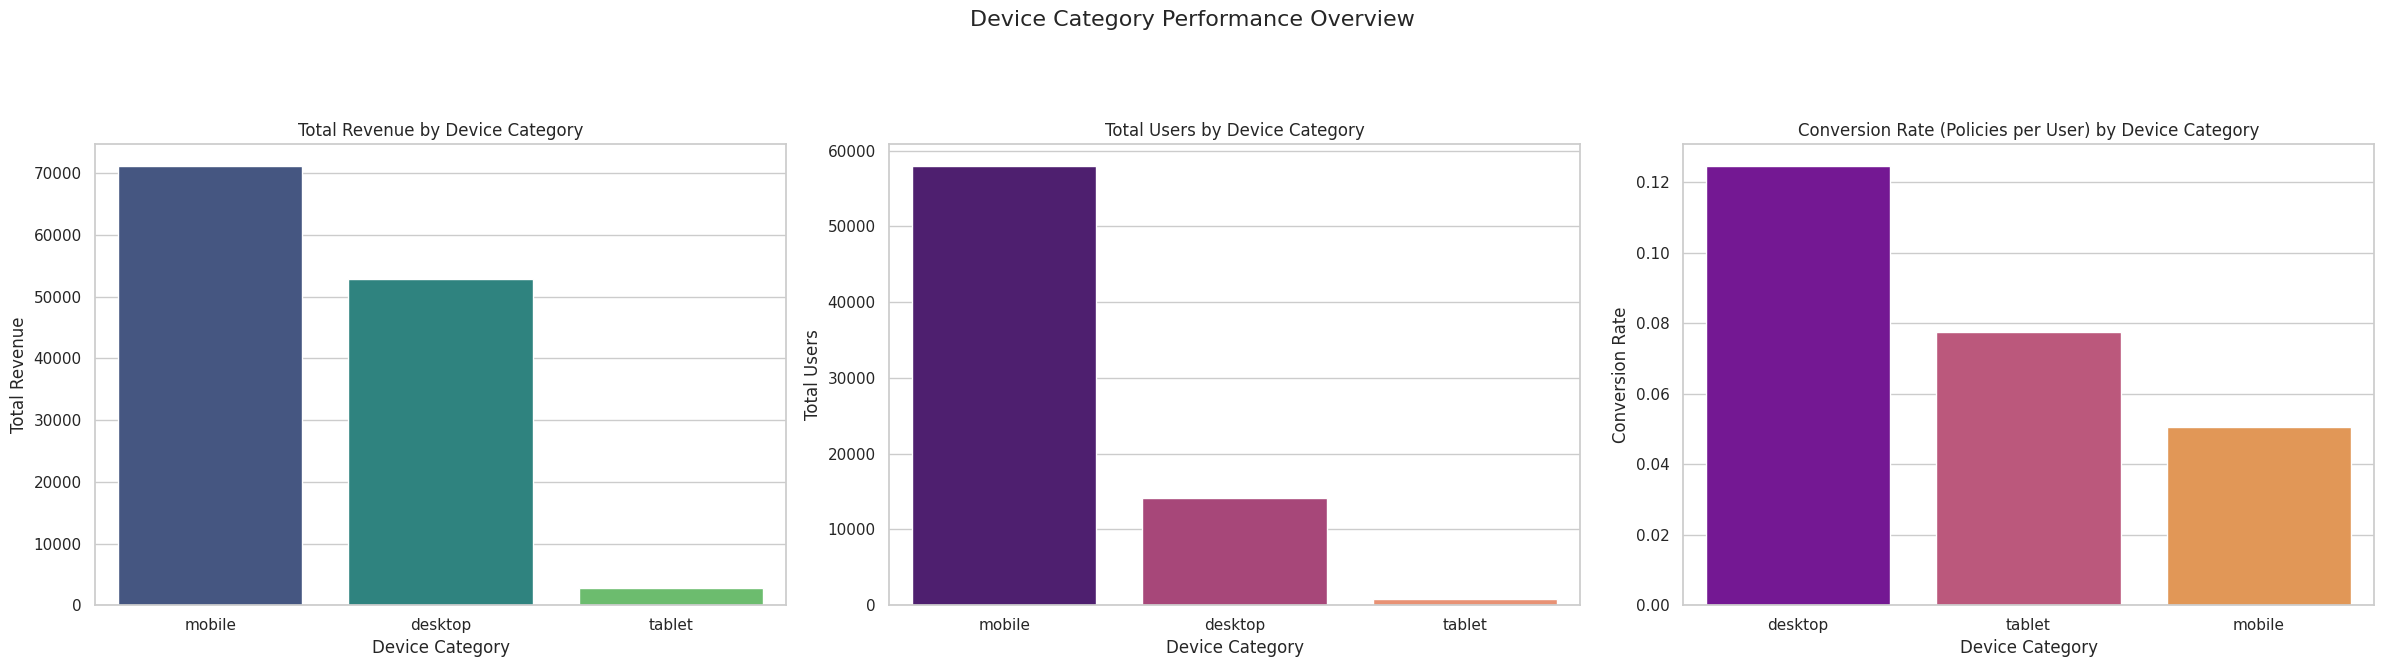

In [48]:
# Aggregate data by 'Device Category'
device_category_df = df.groupby('Device Category').agg(
    total_users=('Users', 'sum'),
    total_revenue=('Revenue', 'sum'),
    total_policies=('TotalNumberOfInsurancePoliciesPurchaed', 'sum')
).reset_index()

# Calculate conversion rate (policies per user) for device category
device_category_df['conversion_rate'] = device_category_df['total_policies'] / device_category_df['total_users']

# Set up the plotting style
sns.set_theme(style="whitegrid")

# Create a figure with a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Device Category Performance Overview', fontsize=16)

# Plot 1: Total Revenue by Device Category
sns.barplot(x='Device Category', y='total_revenue', data=device_category_df.sort_values(by='total_revenue', ascending=False), palette='viridis', ax=axes[0], hue='Device Category', legend=False)
axes[0].set_title('Total Revenue by Device Category')
axes[0].set_xlabel('Device Category')
axes[0].set_ylabel('Total Revenue')

# Plot 2: Total Users by Device Category
sns.barplot(x='Device Category', y='total_users', data=device_category_df.sort_values(by='total_users', ascending=False), palette='magma', ax=axes[1], hue='Device Category', legend=False)
axes[1].set_title('Total Users by Device Category')
axes[1].set_xlabel('Device Category')
axes[1].set_ylabel('Total Users')

# Plot 3: Which device category converts better?
sns.barplot(x='Device Category', y='conversion_rate', data=device_category_df.sort_values(by='conversion_rate', ascending=False), palette='plasma', ax=axes[2], hue='Device Category', legend=False)
axes[2].set_title('Conversion Rate (Policies per User) by Device Category')
axes[2].set_xlabel('Device Category')
axes[2].set_ylabel('Conversion Rate')

plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent title overlap
plt.show()

### EDA 3 – Revenue Analysis

Let's analyze the distribution of the `Revenue` column:
- Understand the distribution of revenue.
- Compare the mean and median revenue.
- Identify potential high-value outliers.

We will use a histogram to show the distribution and a boxplot to highlight the median, quartiles, and outliers.

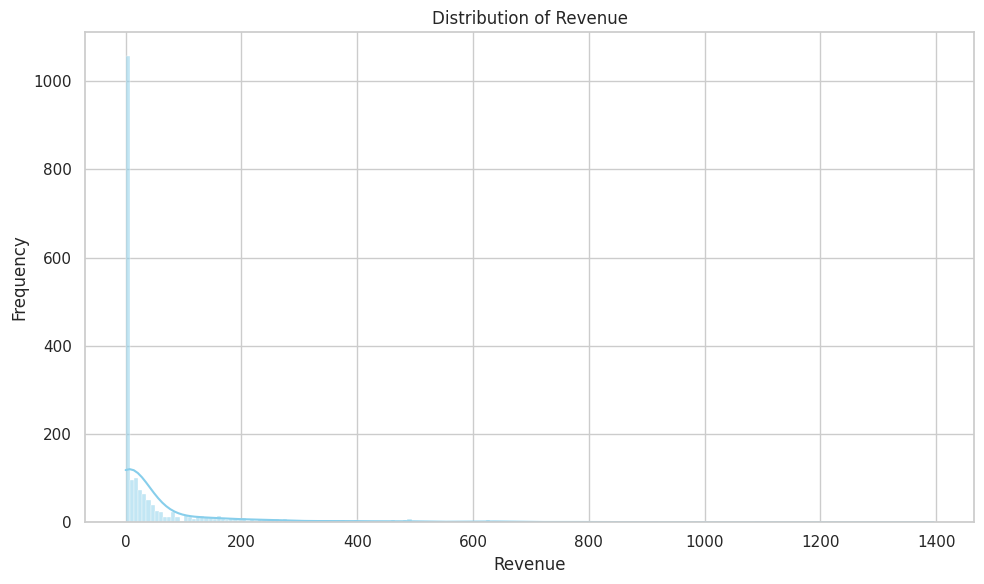

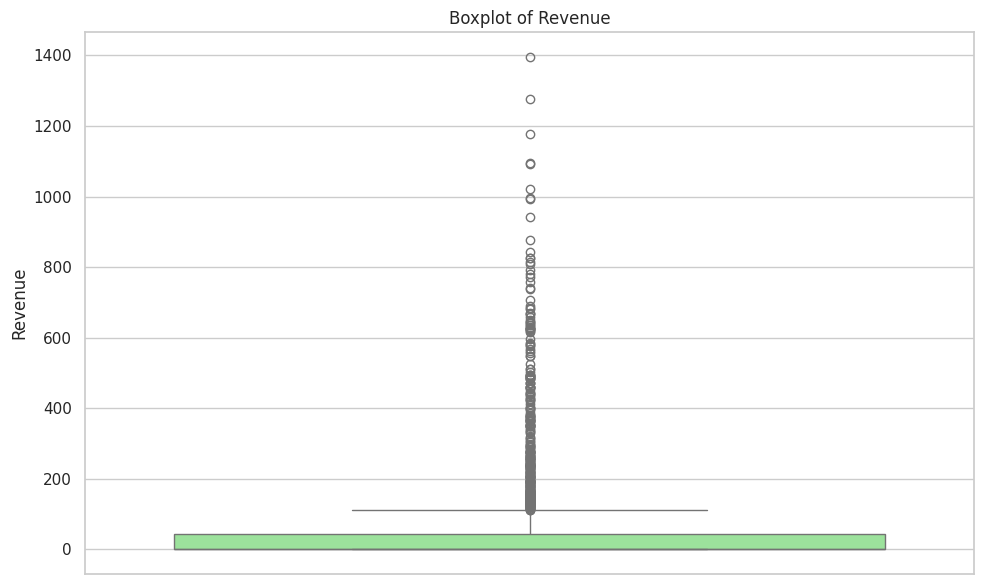

Mean Revenue: 65.63
Median Revenue: 0.00

The mean revenue is greater than the median revenue, indicating a right-skewed distribution, likely due to a few high-value revenues (outliers).


In [49]:
# Distribution of Revenue - Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Revenue'], kde=True, color='skyblue')
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Distribution of Revenue - Boxplot to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Revenue'], color='lightgreen')
plt.title('Boxplot of Revenue')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Calculate Mean vs. Median Revenue
mean_revenue = df['Revenue'].mean()
median_revenue = df['Revenue'].median()

print(f"Mean Revenue: {mean_revenue:.2f}")
print(f"Median Revenue: {median_revenue:.2f}")

if mean_revenue > median_revenue:
    print("\nThe mean revenue is greater than the median revenue, indicating a right-skewed distribution, likely due to a few high-value revenues (outliers).")
elif mean_revenue < median_revenue:
    print("\nThe mean revenue is less than the median revenue, indicating a left-skewed distribution.")
else:
    print("\nThe mean revenue is approximately equal to the median revenue, suggesting a more symmetrical distribution.")

### EDA 4 – User Behaviour

Let's investigate if viewing more pages per session (`Pages / Session`) influences:
- `TotalNumberOfInsuranceQuotes`
- `TotalNumberOfInsurancePoliciesPurchaed`
- `Revenue`

We will use scatter plots to visualize these relationships and calculate their correlation coefficients.

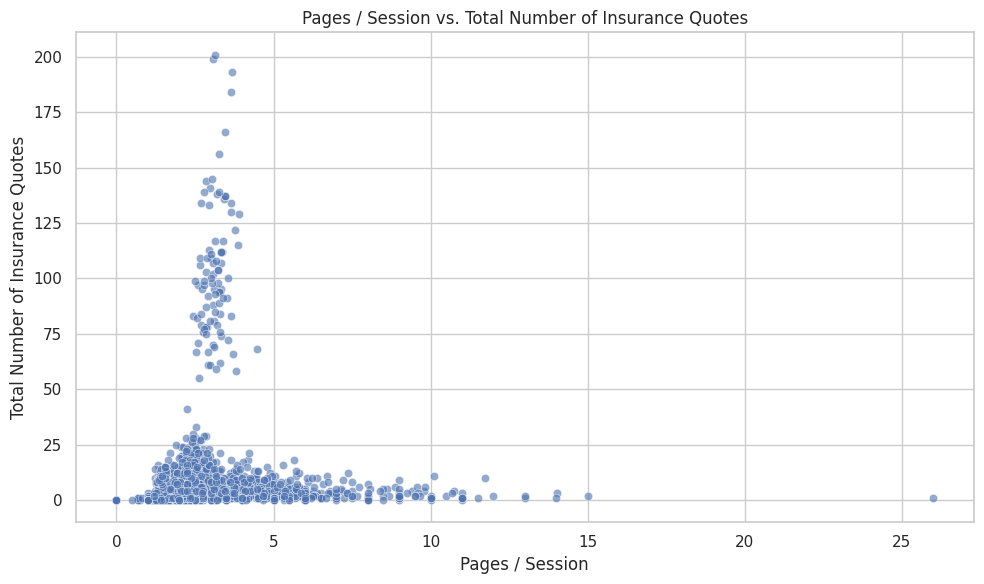

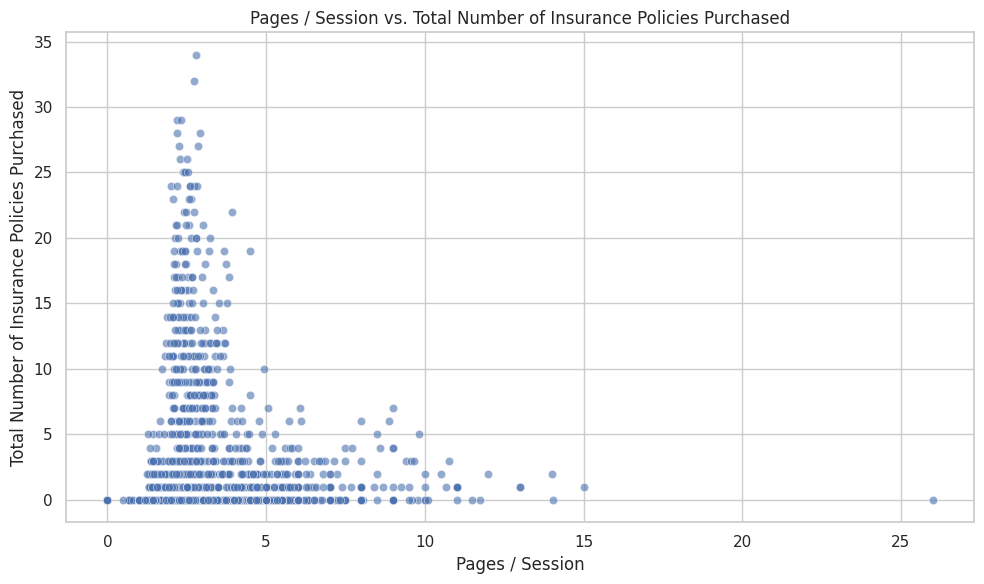

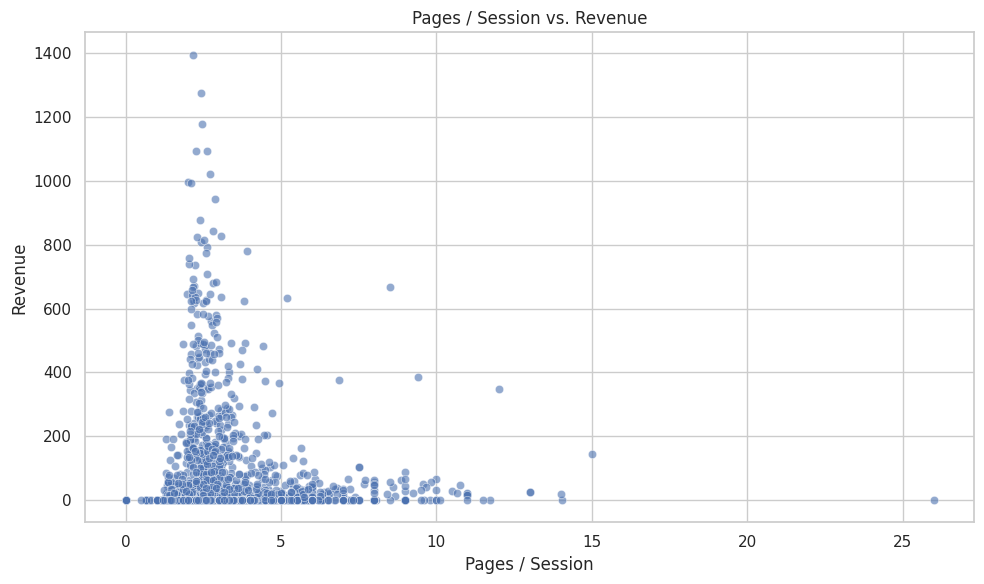


Correlation between Pages / Session and Total Number of Insurance Quotes: 0.03
Correlation between Pages / Session and Total Number of Insurance Policies Purchased: -0.01
Correlation between Pages / Session and Revenue: -0.00


In [50]:
# Scatter plot: Pages / Session vs. TotalNumberOfInsuranceQuotes
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pages / Session', y='TotalNumberOfInsuranceQuotes', data=df, alpha=0.6)
plt.title('Pages / Session vs. Total Number of Insurance Quotes')
plt.xlabel('Pages / Session')
plt.ylabel('Total Number of Insurance Quotes')
plt.tight_layout()
plt.show()

# Scatter plot: Pages / Session vs. TotalNumberOfInsurancePoliciesPurchaed
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pages / Session', y='TotalNumberOfInsurancePoliciesPurchaed', data=df, alpha=0.6)
plt.title('Pages / Session vs. Total Number of Insurance Policies Purchased')
plt.xlabel('Pages / Session')
plt.ylabel('Total Number of Insurance Policies Purchased')
plt.tight_layout()
plt.show()

# Scatter plot: Pages / Session vs. Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pages / Session', y='Revenue', data=df, alpha=0.6)
plt.title('Pages / Session vs. Revenue')
plt.xlabel('Pages / Session')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Calculate and print correlations
correlation_quotes = df['Pages / Session'].corr(df['TotalNumberOfInsuranceQuotes'])
correlation_policies = df['Pages / Session'].corr(df['TotalNumberOfInsurancePoliciesPurchaed'])
correlation_revenue = df['Pages / Session'].corr(df['Revenue'])

print(f"\nCorrelation between Pages / Session and Total Number of Insurance Quotes: {correlation_quotes:.2f}")
print(f"Correlation between Pages / Session and Total Number of Insurance Policies Purchased: {correlation_policies:.2f}")
print(f"Correlation between Pages / Session and Revenue: {correlation_revenue:.2f}")

### EDA 5 – Session Duration

Let's analyze the `Avg. Session Duration` column:
- Understand the distribution of average session duration.
- Identify if longer sessions lead to more purchases.

We will use a histogram for distribution and a scatter plot to examine the relationship with purchases, along with a correlation calculation.

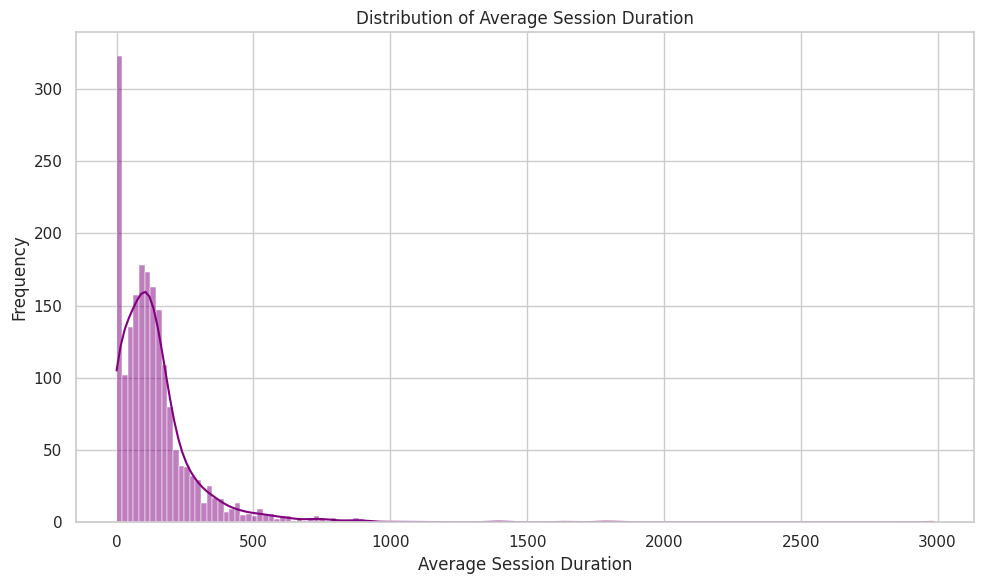

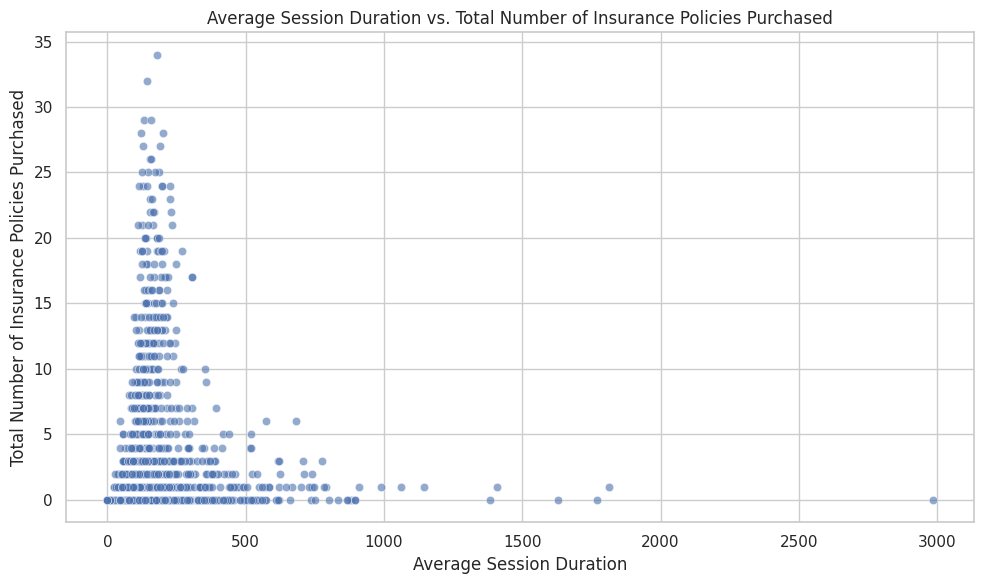


Correlation between Average Session Duration and Total Number of Insurance Policies Purchased: 0.07


In [51]:
# Distribution of Avg. Session Duration - Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Avg. Session Duration'], kde=True, color='purple')
plt.title('Distribution of Average Session Duration')
plt.xlabel('Average Session Duration')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Scatter plot: Avg. Session Duration vs. TotalNumberOfInsurancePoliciesPurchaed
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Avg. Session Duration', y='TotalNumberOfInsurancePoliciesPurchaed', data=df, alpha=0.6)
plt.title('Average Session Duration vs. Total Number of Insurance Policies Purchased')
plt.xlabel('Average Session Duration')
plt.ylabel('Total Number of Insurance Policies Purchased')
plt.tight_layout()
plt.show()

# Calculate and print correlation between session duration and purchases
correlation_session_purchases = df['Avg. Session Duration'].corr(df['TotalNumberOfInsurancePoliciesPurchaed'])

print(f"\nCorrelation between Average Session Duration and Total Number of Insurance Policies Purchased: {correlation_session_purchases:.2f}")

### EDA 6 – Correlation Analysis

Let's analyze the correlations between all numerical features.
This will help us understand the linear relationships between different variables, such as:
- `Users` ↔ `Revenue`
- `TotalNumberOfInsuranceQuotes` ↔ `TotalNumberOfInsurancePoliciesPurchaed`
- `Pages / Session` ↔ `Revenue`
- `Avg. Session Duration` ↔ `Revenue`

We will calculate the correlation matrix and visualize it using a heatmap.

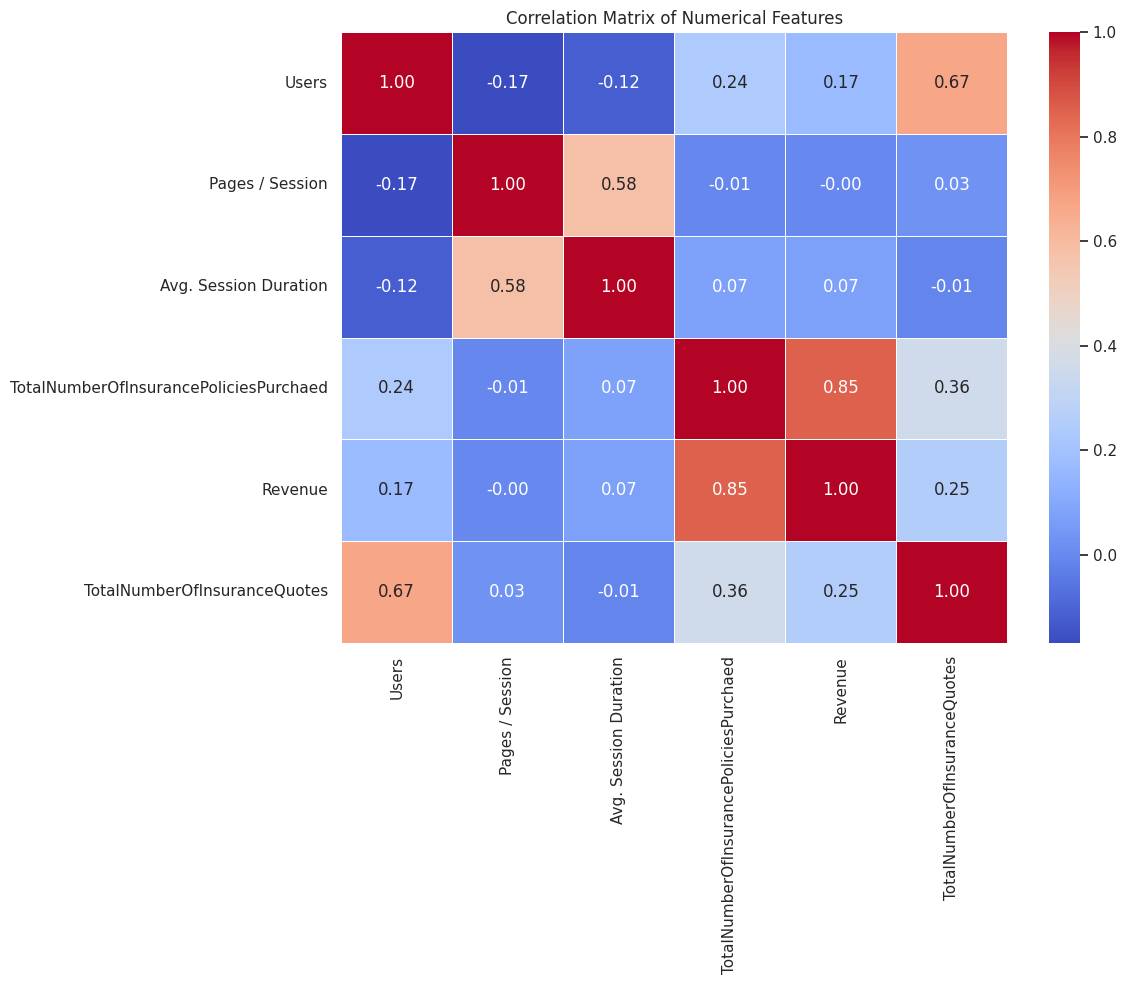

In [52]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### EDA 7 – KPIs

Let's calculate the key performance indicators (KPIs) that will be useful for a dashboard:
- Total Users
- Total Revenue
- Total Policies Purchased
- Total Quotes
- Average Revenue
- Average Session Duration

In [53]:
# Calculate KPIs
total_users_kpi = df['Users'].sum()
total_revenue_kpi = df['Revenue'].sum()
total_policies_kpi = df['TotalNumberOfInsurancePoliciesPurchaed'].sum()
total_quotes_kpi = df['TotalNumberOfInsuranceQuotes'].sum()
average_revenue_kpi = df['Revenue'].mean()
average_session_duration_kpi = df['Avg. Session Duration'].mean()

# Print KPIs
print(f"Total Users: {total_users_kpi:,}")
print(f"Total Revenue: ${total_revenue_kpi:,.2f}")
print(f"Total Policies Purchased: {total_policies_kpi:,}")
print(f"Total Quotes: {total_quotes_kpi:,}")
print(f"Average Revenue: ${average_revenue_kpi:,.2f}")
print(f"Average Session Duration: {average_session_duration_kpi:,.2f} seconds")

Total Users: 72,894
Total Revenue: $126,853.55
Total Policies Purchased: 4,749
Total Quotes: 17,387
Average Revenue: $65.63
Average Session Duration: 144.08 seconds


### EDA 8 – Top Performers

Let's identify the top performers across different categories:
- Top marketing channel by revenue
- Top marketing channel by users
- Top device by revenue
- Top device by purchases

These insights can be valuable for business strategy.

In [54]:
# Top marketing channel by revenue
top_channel_revenue = df.groupby('Marketing Channel')['Revenue'].sum().nlargest(1)
print("\nTop Marketing Channel by Revenue:")
print(top_channel_revenue)

# Top marketing channel by users
top_channel_users = df.groupby('Marketing Channel')['Users'].sum().nlargest(1)
print("\nTop Marketing Channel by Users:")
print(top_channel_users)

# Top device by revenue
top_device_revenue = df.groupby('Device Category')['Revenue'].sum().nlargest(1)
print("\nTop Device Category by Revenue:")
print(top_device_revenue)

# Top device by purchases
top_device_purchases = df.groupby('Device Category')['TotalNumberOfInsurancePoliciesPurchaed'].sum().nlargest(1)
print("\nTop Device Category by Policies Purchased:")
print(top_device_purchases)


Top Marketing Channel by Revenue:
Marketing Channel
Aggregators    73391.98
Name: Revenue, dtype: float64

Top Marketing Channel by Users:
Marketing Channel
Organic Search    26740
Name: Users, dtype: int64

Top Device Category by Revenue:
Device Category
mobile    71155.31
Name: Revenue, dtype: float64

Top Device Category by Policies Purchased:
Device Category
mobile    2925
Name: TotalNumberOfInsurancePoliciesPurchaed, dtype: int64
